# Funciones básicas para armar ST-DIP

Author: Evelyn Cueva
Created: 2023-09-02


## MapNet con Flax NNX

Mapnet is a fully connected neural network with relu activations. It takes as input coordinate (2D or 3D) and outputs a feature vector of a specified dimension.

In [1]:
from typing import Sequence
import jax
import jax.numpy as jnp
from flax import nnx

class MapNetNNX(nnx.Module):
    """
    Mapping network implementado en Flax NNX.

    Construye una red feed-forward con varias capas ocultas `Linear` seguidas de
    funciones de activación ReLU, y una capa de salida lineal.

    Parameters
    ----------
    in_features : int
        Número de características de entrada (dimensión de la primera capa).
        Por ejemplo, 3 si se pasa un vector (x, y, z).
    hidden_sizes : Sequence[int]
        Lista con el número de neuronas en cada capa oculta.
        Ejemplo: (8, 8) crea dos capas ocultas de 8 unidades cada una.
    out_features : int
        Número de neuronas de la capa de salida. Por ejemplo, 64 si se requiere
        un vector latente de tamaño 64.
    rngs : nnx.Rngs
        Generador de números aleatorios de NNX para inicializar los parámetros.

    Example
    -------
    >>> rngs = nnx.Rngs(0)
    >>> model = MapNetNNX(in_features=3, hidden_sizes=(8, 8), out_features=64, rngs=rngs)
    >>> x = jnp.ones((1, 3))     # batch=1, input=(x,y,z)
    >>> y = model(x)             # salida de shape (1, 64)
    >>> y.shape
    (1, 64)
    """

    def __init__(self,
                 in_features: int,
                 hidden_sizes: Sequence[int],
                 out_features: int,
                 rngs: nnx.Rngs):
        # Construcción de las capas ocultas
        self.hidden: list[nnx.Linear] = []
        prev = in_features
        for i, h in enumerate(hidden_sizes):
            # Capa densa oculta de tamaño h
            self.hidden.append(nnx.Linear(prev, h, rngs=rngs))
            prev = h

        # Capa de salida que proyecta a out_features
        self.out = nnx.Linear(prev, out_features, rngs=rngs)

    def __call__(self, x: jax.Array) -> jax.Array:
        """
        Ejecuta el forward pass de la red.

        Parameters
        ----------
        x : jax.Array
            Entrada de forma (batch, in_features) o (..., in_features).

        Returns
        -------
        jax.Array
            Salida de forma (..., out_features).
        """
        # Pasar por cada capa oculta + ReLU
        for layer in self.hidden:
            x = layer(x)
            x = jax.nn.relu(x)

        # Proyección final sin activación
        x = self.out(x)
        return x


### Ejemplo de uso de MapNetNNX

El siguiente ejemplo recibe un valor $x$ y entrena MapNetNNX para aproximar la función $y = sin(x).$ 

In [3]:
import optax

# === Datos sintéticos: y = sin(x) con algo de ruido ===
key = jax.random.key(0)
x_train = jax.random.uniform(key, (1024, 1), minval=-jnp.pi, maxval=jnp.pi)
y_train = jnp.sin(x_train) + 0.05 * jax.random.normal(jax.random.split(key)[0], x_train.shape)

# === Modelo y optimizador ===
rngs = nnx.Rngs(42)
model = MapNetNNX(in_features=1, hidden_sizes=(64, 64), out_features=1, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# === Función de pérdida ===
def loss_fn(model, xb, yb):
    preds = model(xb) # ocupa la definicion de _call_ del modelo
    return jnp.mean((preds - yb) ** 2)

# === Un paso de entrenamiento ===
def train_step(model, optimizer, xb, yb):
    def _loss(m): # generico, es para la derivacion automática
        return loss_fn(m, xb, yb) #solo depende del modelo, datos de entrenamiento y datos verdaderos
    loss, grads = nnx.value_and_grad(_loss)(model) #calculo de gradientes nada que ver con el optimizador
    optimizer.update(model, grads)  # actualiza los parámetros del modelo in-place con el paso del metodo de descenso (optimizer).
    return loss

# === Loop de entrenamiento simple ===
batch_size = 128
n_steps = 2000

for step in range(1, n_steps + 1):
    # muestreo mini-batch
    k1, key = jax.random.split(key)
    idx = jax.random.choice(k1, x_train.shape[0], (batch_size,), replace=False)
    xb, yb = x_train[idx], y_train[idx]

    l = train_step(model, optimizer, xb, yb)

    if step % 200 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# === Prueba rápida ===
x_test = jnp.linspace(-jnp.pi, jnp.pi, 200).reshape(-1, 1)
y_pred = model(x_test)
print("Pred sample:", y_pred[:5].flatten())

step  200 | loss 0.023537
step  400 | loss 0.004284
step  600 | loss 0.003022
step  800 | loss 0.002937
step 1000 | loss 0.002413
step 1200 | loss 0.002712
step 1400 | loss 0.003301
step 1600 | loss 0.002392
step 1800 | loss 0.002202
step 2000 | loss 0.004112
Pred sample: [-0.0099616  -0.0394522  -0.06894397 -0.09843505 -0.12792608]


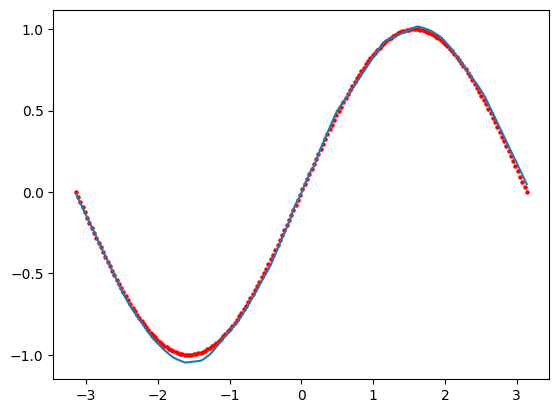

In [4]:
import matplotlib.pyplot as plt

plt.plot(x_test, y_pred, label='Predicción')
plt.scatter(x_test, jnp.sin(x_test), color='r', s=5, label='Verdadero')

## Decoder Net

In [2]:
from typing import List, Optional, Tuple
import jax, jax.numpy as jnp
from flax import nnx

# ---------- util ----------
def upsample_2d(x: jax.Array, scale: int = 2, method: str = "nearest") -> jax.Array:
    if scale == 1:
        return x
    # NHWC, nearest
    x = jnp.repeat(x, scale, axis=1)
    x = jnp.repeat(x, scale, axis=2)
    return x

# ---------- bloques ----------
class ConvBNReLU(nnx.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: Tuple[int,int]=(3,3),
        strides: Tuple[int,int]=(1,1),
        momentum: float = 0.99,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.conv = nnx.Conv(
            in_channels, out_channels,
            kernel_size=kernel_size,
            strides=strides,
            padding="SAME",
            rngs=rngs,
        )
        self.bn = nnx.BatchNorm(
            num_features=out_channels,
            momentum=momentum,
            epsilon=1e-5,
            axis=-1, 
            rngs=rngs,
        )

    def __call__(self, x: jax.Array, training: bool) -> jax.Array:
        x = self.conv(x)
        x = self.bn(x, use_running_average=not training)
        return jax.nn.relu(x)

class DecoderNNX(nnx.Module):
    """
    Decoder 2D NHWC sin lazy-build.
    Estructura: 2x(ConvBNReLU) -> Upsample -> [levels * (2x(ConvBNReLU) -> Upsample)] -> 2x(ConvBNReLU) -> Conv final
    """
    def __init__(
        self,
        in_channels: int,            # 1 si tu MapNet->reshape añade un solo canal
        features: int = 128,
        momentum: float = 0.99,
        levels: int = 3,
        out_features: int = 2,
        upsampling_method: str = "nearest",
        upsampling_factor: int = 2,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.features = features
        self.levels = levels
        self.out_features = out_features
        self.upsampling_method = upsampling_method
        self.upsampling_factor = upsampling_factor
        self.rngs = rngs if rngs is not None else nnx.Rngs(0)

        # Head
        self.head: List[ConvBNReLU] = [
            ConvBNReLU(in_channels, features, momentum=momentum, rngs=self.rngs),
            ConvBNReLU(features,    features, momentum=momentum, rngs=self.rngs),
        ]

        # Body
        self.body: List[List[ConvBNReLU]] = []
        for _ in range(levels):
            self.body.append([
                ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
                ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
            ])

        # Tail
        self.tail: List[ConvBNReLU] = [
            ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
            ConvBNReLU(features, features, momentum=momentum, rngs=self.rngs),
        ]

        # Conv final
        self.final_conv = nnx.Conv(
            features, out_features,
            kernel_size=(3,3),
            strides=(1,1),
            padding="SAME",
            rngs=self.rngs,
        )

    def __call__(self, x: jax.Array, training: bool) -> jax.Array:
        for blk in self.head:
            x = blk(x, training=training)

        x = upsample_2d(x, scale=self.upsampling_factor, method=self.upsampling_method)

        for level_blocks in self.body:
            for blk in level_blocks:
                x = blk(x, training=training)
            x = upsample_2d(x, scale=self.upsampling_factor, method=self.upsampling_method)

        for blk in self.tail:
            x = blk(x, training=training)

        return self.final_conv(x)

### Ejemplo con DecoderNetNNX
Ingresa una matriz de ruido gaussiano de tamaño 8x8 y obtiene una imagen de tamaño 128x128x2.

In [6]:
# --------- objetivo sintético suave 128x128x2 ---------
def make_target(H=128, W=128):
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")
    R = jnp.sqrt(X**2 + Y**2)

    # Canal 0: disco gaussiano
    sigma = 0.35
    ch0 = jnp.exp(- (R**2) / (2 * sigma**2))

    # Canal 1: patrón sinusoidal suave
    ch1 = 0.5 * (jnp.sin(3*jnp.pi*X) * jnp.sin(3*jnp.pi*Y)) + 0.5

    target = jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)
    target = target[None, ...]               # (1, H, W, 2) para NHWC con batch=1
    return target

# --------- setup experimento DIP-like ---------
key = jax.random.key(0)

levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3) = 16
H_out = 128
W_out = 128
H_in = H_out // scale_total       # 8
W_in = W_out // scale_total       # 8

assert H_out % scale_total == 0 and W_out % scale_total == 0, "Ajusta niveles o upsampling_factor."

# Entrada (ruido fijo) y objetivo
z = jax.random.normal(key, (1, H_in, W_in, 1))  # NHWC
y_true = make_target(H_out, W_out)              # (1, 128, 128, 2)

# Modelo y optimizador (NNX >= 0.11)
rngs = nnx.Rngs(42)
model = DecoderNNX(in_channels=1, features=64, levels=levels,
                   out_features=2, upsampling_factor=up, rngs=rngs)
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# Pérdida MSE simple
def loss_fn(m: DecoderNNX, z: jax.Array, y: jax.Array):
    yhat = m(z, training=True)
    return jnp.mean((yhat - y) ** 2)

# Un paso de entrenamiento (API nueva: update(model, grads))
def train_step(m: DecoderNNX, opt: nnx.Optimizer, z: jax.Array, y: jax.Array):
    def _loss(m_):
        return loss_fn(m_, z, y)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)
    return loss

# Loop simple
# Sin batch, todo el objetivo a la vez
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, z, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# Evaluación (usar promedios corridos en BN)
y_pred = model(z, training=False)
print("Output shape:", y_pred.shape, "| min/max:", float(y_pred.min()), float(y_pred.max()))

2025-09-09 10:54:29.449805: W external/xla/xla/tsl/framework/bfc_allocator.cc:310] Allocator (GPU_0_bfc) ran out of memory trying to allocate 2.06GiB with freed_by_count=0. The caller indicates that this is not a failure, but this may mean that there could be performance gains if more memory were available.


step  150 | loss 0.000262
step  300 | loss 0.000118
step  450 | loss 0.000075
step  600 | loss 0.000054
step  750 | loss 0.000041
step  900 | loss 0.000033
step 1050 | loss 0.000030
step 1200 | loss 0.000023
step 1350 | loss 0.000019
step 1500 | loss 0.000017
Output shape: (1, 128, 128, 2) | min/max: -0.05810176953673363 1.0155140161514282


(-0.5, 127.5, 127.5, -0.5)

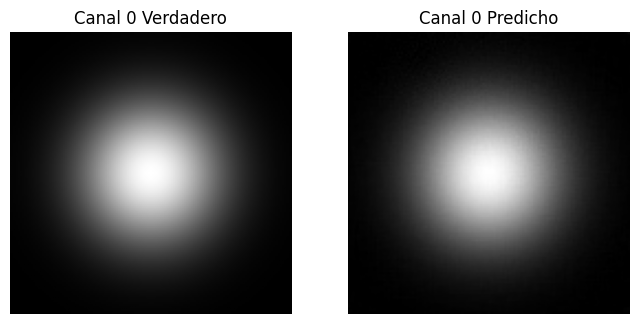

In [7]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1)
plt.imshow(jnp.abs(y_true[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Verdadero")
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(jnp.abs(y_pred[0,:,:,0]), cmap='gray')
plt.title("Canal 0 Predicho")
plt.axis('off')

## Unión de MapNeet + Decoder

In [3]:
from typing import Sequence, Tuple, Optional
import jax
import jax.numpy as jnp
from flax import nnx

class TDIPNNX(nnx.Module):
    """
    tDIP en NNX: MapNet -> reshape (px, py) -> añadir canal -> Decoder.

    map_in_features: dimensión de t
    map_hidden_sizes: capas de MapNet
    cnn_latent_shape: (px, py) que produce MapNet (antes de añadir canal)
    decoder_features: # filtros internos del decoder
    momentum: BN momentum dentro del decoder
    levels: # de niveles [2xConvBNReLU -> upsample] del decoder
    out_features: canales de salida
    upsampling_method: 'nearest' o 'bilinear'
    upsampling_factor: factor de upsample por nivel
    rngs: RNGs compartidos
    """
    def __init__(
        self,
        map_in_features: int,
        map_hidden_sizes: Sequence[int],
        cnn_latent_shape: Tuple[int, int],
        decoder_features: int,
        momentum: float,
        levels: int,
        out_features: int = 2,
        upsampling_method: str = "nearest",
        upsampling_factor: int = 2,
        rngs: Optional[nnx.Rngs] = None,
    ):
        self.px, self.py = cnn_latent_shape
        self.rngs = rngs if rngs is not None else nnx.Rngs(0)

        # 1) MapNet: (N, map_in_features) -> (N, px*py)
        self.mapnet = MapNetNNX(
            in_features=map_in_features,
            hidden_sizes=map_hidden_sizes,
            out_features=self.px * self.py,
            rngs=self.rngs,
        )

        # 2) Decoder: entrada NHWC con C=1 (después del reshape)
        self.decoder = DecoderNNX(
            in_channels=1,                  
            features=decoder_features,
            momentum=momentum,
            levels=levels,
            out_features=out_features,
            upsampling_method=upsampling_method,
            upsampling_factor=upsampling_factor,
            rngs=self.rngs,
        )

    def __call__(self, t: jax.Array, training: bool) -> jax.Array:
        """
        t: (N, map_in_features)  ->  y: (N, H_out, W_out, out_features)
        """
        # MapNet
        x = self.mapnet(t)                               # (N, px*py)

        # Reshape + canal
        x = jnp.reshape(x, (x.shape[0], self.px, self.py, 1))  # (N, px, py, 1)

        # Decoder
        y = self.decoder(x, training=training)           # (N, H_out, W_out, out_features)
        return y


### Ejemplo con MapNetNNX + DecoderNNX

Este ejemplo recibe un vector de tiempos $t$ de tamaño $N$ y pasa por MapNetNNx para obtener una espacio latente de $8\times 8$ y luego pasa por DecoderNNX para obtener una imagen de tamaño $N\times128\times 128 \times 2$.


In [41]:
# ====== dataset dinámico sintético ======
def make_dyn_target_batch(t_vals: jax.Array, H: int, W: int) -> jax.Array:
    """
    t_vals: (N, 1) en [0,1]
    return: (N, H, W, 2)
    """
    ys = jnp.linspace(-1, 1, H)
    xs = jnp.linspace(-1, 1, W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")

    def frame_at_t(t):
        theta = 2 * jnp.pi * t
        cx, cy = 0.3 * jnp.cos(theta), 0.3 * jnp.sin(theta)
        sigma = 0.25
        ch0 = jnp.exp(-((X - cx)**2 + (Y - cy)**2) / (2 * sigma**2))
        # patrón sinusoidal que rota con t
        kx, ky = 3.0, 3.0
        ch1 = 0.5 * (jnp.sin(kx*(X*jnp.cos(theta) - Y*jnp.sin(theta)) + 2*jnp.pi*t) *
                     jnp.sin(ky*(X*jnp.sin(theta) + Y*jnp.cos(theta)) + 2*jnp.pi*t)) + 0.5
        return jnp.stack([ch0, ch1], axis=-1)  # (H, W, 2)

    # vmap sobre la primera dimensión de t_vals
    return jax.vmap(lambda tau: frame_at_t(tau[0]))(t_vals)  # (N, H, W, 2)

# ====== configuración del experimento ======
key = jax.random.key(0)

# Dimensiones
levels = 3
up = 2
scale_total = up ** (1 + levels)  # 2^(1+3)=16
px, py = 8, 8                      # tamaño del "latente imagen" que produce MapNet
H_out, W_out = px * scale_total, py * scale_total  # 128x128
assert H_out == 128 and W_out == 128

# Secuencia temporal
N = 31
t_vals = jnp.linspace(0.0, 1.0, N).reshape(N, 1)   # (N, map_in_features=1)
y_true = make_dyn_target_batch(t_vals, H_out, W_out)  # (N, 128, 128, 2)

# ====== modelo + optimizador (NNX >= 0.11) ======
rngs = nnx.Rngs(42)
model = TDIPNNX(
    map_in_features=1,
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(px, py),
    decoder_features=64,
    momentum=0.9,
    levels=levels,
    out_features=2,              # 2 canales (p.ej., real/imag)
    upsampling_method="nearest",
    upsampling_factor=up,
    rngs=rngs,
)

optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)

# ====== pérdida y paso de entrenamiento ======
def loss_fn(m: TDIPNNX, t_batch: jax.Array, y_batch: jax.Array):
    yhat = m(t_batch, training=True)
    return jnp.mean((yhat - y_batch) ** 2)

def train_step(m: TDIPNNX, opt: nnx.Optimizer, t_batch: jax.Array, y_batch: jax.Array):
    def _loss(m_):
        return loss_fn(m_, t_batch, y_batch)
    loss, grads = nnx.value_and_grad(_loss)(m)
    opt.update(m, grads)  # API nueva: (model, grads)
    return loss

# ====== loop (full-batch para simplificar) ======
n_steps = 1500
for step in range(1, n_steps + 1):
    l = train_step(model, optimizer, t_vals, y_true)
    if step % 150 == 0:
        print(f"step {step:4d} | loss {float(l):.6f}")

# ====== evaluación (BN en modo inferencia) ======
y_pred = model(t_vals, training=False)
print("y_pred shape:", y_pred.shape, " | min/max:", float(y_pred.min()), float(y_pred.max()))


2025-09-09 11:33:06.746067: W external/xla/xla/tsl/framework/bfc_allocator.cc:501] Allocator (GPU_0_bfc) ran out of memory trying to allocate 124.00MiB (rounded to 130023424)requested by op 
If the cause is memory fragmentation maybe the environment variable 'TF_GPU_ALLOCATOR=cuda_malloc_async' will improve the situation. 
Current allocation summary follows.
Current allocation summary follows.
2025-09-09 11:33:06.747225: W external/xla/xla/tsl/framework/bfc_allocator.cc:512] ***************************___****************************************************************xxxxxx
E0909 11:33:06.747251 2356359 pjrt_stream_executor_client.cc:3008] Execution of replica 0 failed: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 130023424 bytes. [tf-allocator-allocation-error='']


ValueError: RESOURCE_EXHAUSTED: Out of memory while trying to allocate 130023424 bytes.

#### Visuallización de resultados temporales sintéticos

Dado que la salida del ejemplo tiene dos canales, se visualiza el módulo de la imagen.

In [20]:
# ===== Video helpers para (N, H, W, C) =====
from typing import Literal, Optional
import numpy as np
import imageio.v3 as iio

def prepare_frames_uint8(
    frames: np.ndarray,
    visualization: Literal["magnitude", "channel"] = "magnitude",
    channel: int = 0,
    normalize: Literal["global", "per_frame"] = "global",
) -> np.ndarray:
    """
    Convierte frames (N,H,W,C) -> (N,H,W) uint8 para video.
    - visualization="magnitude": usa sqrt(ch0^2 + ch1^2) (requiere C>=2).
    - visualization="channel": usa un canal específico (channel=0/1/...).
    - normalize="global": mismo contraste para todo el video.
      "per_frame": normaliza cada frame (útil si varía mucho la intensidad).
    """
    arr = np.asarray(frames)  # por si viene como jax.Array
    if arr.ndim == 3:  # (N,H,W) sin canales
        gray = arr
    else:
        assert arr.ndim == 4, f"Se esperaba (N,H,W,C), obtuve {arr.shape}"
        if visualization == "magnitude":
            assert arr.shape[-1] >= 2, "Se requieren >=2 canales para magnitud."
            gray = np.sqrt(arr[..., 0]**2 + arr[..., 1]**2)
        else:  # "channel"
            gray = arr[..., channel]

    if normalize == "global":
        vmin, vmax = float(gray.min()), float(gray.max())
        if vmax <= vmin:
            gray_u8 = np.zeros_like(gray, dtype=np.uint8)
        else:
            gray_u8 = ((gray - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)
    else:  # "per_frame"
        N = gray.shape[0]
        gray_u8 = np.empty_like(gray, dtype=np.uint8)
        for i in range(N):
            g = gray[i]
            vmin, vmax = float(g.min()), float(g.max())
            if vmax <= vmin:
                gray_u8[i] = np.zeros_like(g, dtype=np.uint8)
            else:
                gray_u8[i] = ((g - vmin) / (vmax - vmin) * 255.0).clip(0, 255).astype(np.uint8)

    return gray_u8  # (N,H,W), uint8


def save_gif(frames_u8: np.ndarray, path: str = "video.gif", fps: int = 15):
    """
    Guarda GIF animado con imageio (no requiere ffmpeg).
    """
    assert frames_u8.ndim == 3, "Se espera (N,H,W) uint8"
    duration = 1.0 / fps  # seg por frame
    iio.imwrite(path, frames_u8, extension=".gif", duration=duration, loop=0)
    print(f"GIF guardado en: {path}")


In [ ]:
# y_pred: (N, H, W, 2)  # p. ej., salida de tu TDIPNNX (2 canales = re/imag)
frames_u8 = prepare_frames_uint8(y_pred, visualization="magnitude", normalize="global")

# GIF (no requiere ffmpeg)
save_gif(frames_u8, "tdip.gif")

GIF guardado en: tdip.gif
MP4 guardado en: tdip.mp4


In [ ]:
frames_u8_true = prepare_frames_uint8(y_true, visualization="magnitude", normalize="global")
save_gif(frames_u8_true, "tdip_true.gif")

GIF guardado en: tdip_true.gif
MP4 guardado en: tdip_true.mp4


### Ejemplo con datos reales MRI en numpy

El espacio latente tendrá cierto comportamiento, por ejemplos, puntos de un círculo/hélice/etc. La red es MapNetNNX + DecoderNNX.
Un modelo de T-DIP considera un espacio $k$ sampleado, en el caso, el sampleo es radial. Se incluyen mapas de sensibilidad de las bobinas. Esto cambia principalmente la función de pérdida, que en este caso es la pérdida en el espacio $k$.

#### Cargar los datos disponibles desde el resonador


In [5]:
import jax.numpy as jnp 
from inrmri.radial_acquisitions import RadialAcquisitions
from inrmri.new_radon import get_weight_freqs

folder = '/home/egcuevaj/repositories/SR-ST-DIP-cMRI/data/Josefa-CineLR/'
print("Loading data...")

data = jnp.load(folder + 'sl5-data.npy')
trajs = jnp.load(folder + 'sl5-traj.npy')
radial_acquisition = RadialAcquisitions(trajs, data)

csmap = jnp.load(folder + 'sl5-csmap.npy')

# Reconstrucción con iterative sense (la reco más básica cuando se conocen las bobinas)
reco_sense = jnp.load(folder + 'sl5-reco-sense.npy')

# Reconstrucción con GRASP (una reco que además de las bobinas incluye regularización (TV en tiempo))
reco_grasp = jnp.load(folder + 'sl5-reco-grasp.npy')

print("Data loaded!")
print(radial_acquisition)
print(f"csmap has shape {csmap.shape}: {csmap.shape[0]} sensitivity maps of size {csmap.shape[1:3]}")
print(f"reco_sense has shape: {reco_sense.shape}: {reco_sense.shape[-1]} frames of size {reco_sense.shape[:2]}")
print(f"reco_grasp has shape: {reco_grasp.shape}: {reco_grasp.shape[-1]} frames of size {reco_grasp.shape[:2]}")

Loading data...
Data loaded!
Radial adquisition: 28 coils, 31 frames of 15 spokes each, 256 samples per spokes.
csmap has shape (28, 256, 256): 28 sensitivity maps of size (256, 256)
reco_sense has shape: (256, 256, 31): 31 frames of size (256, 256)
reco_grasp has shape: (256, 256, 31): 31 frames of size (256, 256)


Se reorganizan los datos para que sean compatibles con el modelo y la función de pérdida. Esto lo reazliza la función `radial_acquisition.generate_dataset()`.

Returns
- dataX: Trayectorias de muestreo con información temporal añadida.

         Forma: `(n_frames * n_spokes_per_frame, n_samples + 1, 2)`.

- dataY : Datos de Fourier adquiridos en k-space.
        
         Forma: `(n_frames * n_spokes_per_frame, n_coils, n_samples, 1)`.

In [6]:
print("Creating dataset...")
train_X_full, train_Y = radial_acquisition.generate_dataset()
train_Y = 100 * train_Y  # Escalado de la señal para mantener un orden de magnitud adecuado
print(train_X_full.shape, train_Y.shape)

Creating dataset...
(465, 257, 2) (465, 28, 256, 1)


In [7]:
from inrmri.radial_acquisitions import kFOV_limit_from_spoke_traj, check_correct_dataset

# -------------------------------------------------------------------
# Chequeo de las trayectorias
# -------------------------------------------------------------------
check_correct_dataset(train_X_full)

# Cálculo del límite de FOV a partir de un spoke de ejemplo
spoke_limit = kFOV_limit_from_spoke_traj(train_X_full[0, 1:, :])

# Escalamiento inicial
scaling_param = 1.0

The trajectories are centered


In [8]:
from inrmri.radon import calculate_angle
from jax import vmap
import jax.numpy as jnp

# Los spokes (kx,ky) pueden representarse solo con alpha, se elimina una dimensión usando eso.
angles = vmap(calculate_angle)(train_X_full[:, 1:]) # hay nframes*n_spokes angles
# Tiempos asociados a cada frame (almacenados en la primera columna de cada spoke)
times = train_X_full[:, 0, 1] 
# times = train_X[:, 0, 0] tiene la misma información 
# Nueva representación de entradas: (angle, time)
train_X = jnp.stack([angles, times], axis=-1)
print("New train_X shape:", train_X.shape)  # (nframes*nspokes, 2)

New train_X shape: (465, 2)


In [9]:
# -------------------------------------------------------------------
# Configuración inicial
# -------------------------------------------------------------------
gtim = reco_grasp # es una imagen en cine 31 frames
print(gtim.shape)
NFRAMES = gtim.shape[-1]          # número de frames dinámicos
IMSHAPE = gtim.shape[:2]          # dimensiones espaciales (px, py)
N = IMSHAPE[0]                    # dimensión lateral (asumiendo cuadrado)
total_cycles = 1                  # número total de ciclos cardiacos en la adquisición

(256, 256, 31)


In [10]:
# Grid temporal normalizado (0 a 1, excluyendo el endpoint)
ts = jnp.linspace(0, 1, gtim.shape[-1], endpoint=False)

#### Estructura de la red con NNx

Input: Puntos de una hélice para un ciclo cardíaco (será como un círculo)

In [11]:
# ================== Helix (latente temporal) ==================
def helix_generator(nframes: int, total_cycles: float):
    t = jnp.linspace(0.0, total_cycles, nframes, endpoint=False)
    return jnp.stack([
        jnp.cos(2*jnp.pi*t),
        jnp.sin(2*jnp.pi*t),
        t / total_cycles
    ], axis=-1)  # (nframes, 3)

def helix_lookup(times_norm: jnp.ndarray, helix: jnp.ndarray) -> jnp.ndarray:
    """times_norm: (B,), helix: (NFRAMES, d) -> (B, d)"""
    nframes = helix.shape[0]
    idx = jnp.floor(times_norm * nframes).astype(jnp.int32) % nframes
    return helix[idx]

helix = helix_generator(NFRAMES, total_cycles) #(31, 3) 
d = helix.shape[1]

In [12]:
# ====== modelo + optimizador (NNX >= 0.11) ======
rngs = nnx.Rngs(42)
px, py = 16, 16                      # tamaño del "latente imagen" que produce MapNet
model = TDIPNNX(
    map_in_features=d,
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(px, py),
    decoder_features=64,
    momentum=0.9,
    levels=3,
    out_features=2,              # 2 canales (p.ej., real/imag)
    upsampling_method="nearest",
    upsampling_factor=2,
    rngs=rngs,
)

Vamos a definir la función de pérdida, dado que la pérdida se calcula en el espacio $k$, se usa la transformada de Radon para llegar al espacio de Fourier y comparar con los datos adquiridos (Fourier slice Theorem).

Radon Operator with coils included to use in the loss function 

In [13]:
import jax.numpy as jnp

def rotate_real(im_hw: jnp.ndarray, angle_rad: float) -> jnp.ndarray:
    """
    Rotación bilineal centrada, tamaño preservado, modo 'constant' (fuera = 0).
    im_hw: (H, W) real
    """
    H, W = im_hw.shape
    cy = (H - 1.0) / 2.0
    cx = (W - 1.0) / 2.0

    c = jnp.cos(angle_rad)
    s = jnp.sin(angle_rad)

    ys = jnp.arange(H)
    xs = jnp.arange(W)
    Y, X = jnp.meshgrid(ys, xs, indexing="ij")  # (H, W)

    # coords de salida -> coords de entrada (rotación inversa)
    Xp = X - cx
    Yp = Y - cy
    Xi =  c*Xp + s*Yp + cx
    Yi = -s*Xp + c*Yp + cy

    # vecinos para bilinear
    x0 = jnp.floor(Xi).astype(jnp.int32); x1 = x0 + 1
    y0 = jnp.floor(Yi).astype(jnp.int32); y1 = y0 + 1

    # máscara válida (modo constant: 0 fuera)
    valid = (Xi >= 0) & (Xi <= W-1) & (Yi >= 0) & (Yi <= H-1)

    # clamp para indexar sin salirte
    x0c = jnp.clip(x0, 0, W-1); x1c = jnp.clip(x1, 0, W-1)
    y0c = jnp.clip(y0, 0, H-1); y1c = jnp.clip(y1, 0, H-1)

    Ia = im_hw[y0c, x0c]
    Ib = im_hw[y0c, x1c]
    Ic = im_hw[y1c, x0c]
    Id = im_hw[y1c, x1c]

    wa = (x1 - Xi) * (y1 - Yi)
    wb = (Xi - x0) * (y1 - Yi)
    wc = (x1 - Xi) * (Yi - y0)
    wd = (Xi - x0) * (Yi - y0)

    out = wa*Ia + wb*Ib + wc*Ic + wd*Id
    out = jnp.where(valid, out, 0.0)
    return out

def rotate_complex(im_hw_cplx: jnp.ndarray, angle_rad: float) -> jnp.ndarray:
    re = rotate_real(im_hw_cplx.real, angle_rad)
    im = rotate_real(im_hw_cplx.imag, angle_rad)
    return re + 1j * im


def radon_integration(img, ds, axis=-1):
    return jnp.sum(img, axis=axis) * ds

def fft1d_shifted(x):
    return jnp.fft.fftshift(jnp.fft.fft(jnp.fft.ifftshift(x, axes=-1), axis=-1), axes=-1)

class ForwardRadonOperatorJAX:
    """
    csmap: (ncoils, N, N) complejo o real (si real, se convierte a complejo)
    """
    def __init__(self, csmap: jnp.ndarray, spclim: float = 0.5, ds: float = 1.0):
        csmap = jnp.asarray(csmap)
        assert csmap.ndim == 3 and csmap.shape[1] == csmap.shape[2], "csmap debe ser (ncoils,N,N)"
        self.csmap = csmap.astype(jnp.complex64) if csmap.dtype.kind != 'c' else csmap
        self.N = csmap.shape[1]
        self.ds = ds
        self.spclim = spclim

    def rotated_csweighted_ims(self, im_bhw_complex: jnp.ndarray, alphas_b: jnp.ndarray) -> jnp.ndarray:
        """
        im_bhw_complex: (B, N, N) complejo
        alphas_b: (B,) rad
        return: (B, ncoils, N, N) complejo
        """
        # ponderar por csmap por-coil
        w = im_bhw_complex[:, None, :, :] * self.csmap[None, :, :, :]  # (B,C,N,N)
        # rotar por ángulo del batch
        def rot_one(sample_coils, a):
            return jax.vmap(lambda z: rotate_complex(z, a))(sample_coils)  # (C,N,N)
        return jax.vmap(rot_one)(w, alphas_b)  # (B,C,N,N)

    def radon_transform(self, rotated_im: jnp.ndarray) -> jnp.ndarray:
        """
        rotated_im: (B, C, N, N) complejo
        return: (B, C, N) complejo  (perfil integrado -> FFT1D centrada)
        """
        prof = radon_integration(rotated_im, self.ds, axis=-1)     # (B,C,N)
        ksp  = fft1d_shifted(prof * self.spclim * 2.0)             # (B,C,N)
        return ksp

In [14]:
radon_op = ForwardRadonOperatorJAX(csmap=jnp.asarray(csmap), spclim=0.5, ds=1.0)

Función de pérdida

In [15]:
# ================== Targets en k-space (robusto a formatos) ==================
def as_complex_kspace(Y: jnp.ndarray) -> jnp.ndarray:
    """
    Convierte Y a complejo shape (B, C, N)
    Admite:
      - (B,C,N) complejo
      - (B,C,N,1) complejo  -> squeeze
      - (B,C,N,2) real      -> Re/Im
    """
    Y = jnp.asarray(Y)
    if Y.ndim == 3 and Y.dtype.kind == 'c':
        return Y
    if Y.ndim == 4 and Y.shape[-1] == 1 and Y.dtype.kind == 'c':
        return jnp.squeeze(Y, axis=-1)
    if Y.ndim == 4 and Y.shape[-1] == 2 and Y.dtype.kind != 'c':
        return Y[..., 0] + 1j * Y[..., 1]
    raise ValueError(f"Formato de Y no soportado: shape={Y.shape}, dtype={Y.dtype}")

# ================== Pérdida compleja ponderada ==================
def complex_mse_weighted(pred: jnp.ndarray, targ: jnp.ndarray, w_11N: jnp.ndarray) -> jnp.ndarray:
    """
    pred, targ: (B, C, N) complejo
    w_11N: (1,1,N)
    """
    dre = (pred.real - targ.real)
    dim = (pred.imag - targ.imag)
    se = dre*dre + dim*dim
    return jnp.mean(se * w_11N)

# ================== Loss NNX (TDIPNNX con salida Re/Im) ==================
def loss_fn(model: "TDIPNNX",
            X: jnp.ndarray,          # (B, 2): [alpha_rad, time_norm]
            Y: jnp.ndarray,          # (B, C, N) complejo o (B,C,N,1)/(B,C,N,2)
            helix: jnp.ndarray,      # (NFRAMES, d)
            radon_op: ForwardRadonOperatorJAX,
            weight_freqs: jnp.ndarray):  # (N,)

    alphas = X[:, 0]
    times  = X[:, 1]
    t_lat  = helix_lookup(times, helix)                # (B, d)

    # Forward (BN en training=True)
    y_hat = model(t_lat, training=True)                # (B, H, W, 2)
    im_c  = y_hat[..., 0] + 1j * y_hat[..., 1]        # (B, H, W) complejo

    # Proyección radial
    rot   = radon_op.rotated_csweighted_ims(im_c, alphas)  # (B, C, N, N) complejo
    kpred = radon_op.radon_transform(rot)                  # (B, C, N) complejo

    ktrue = as_complex_kspace(Y)                           # (B, C, N)
    w = (1.0 + weight_freqs)[None, None, :]               # (1,1,N)

    return complex_mse_weighted(kpred, ktrue, w)

# ================== Paso de entrenamiento ==================
def make_train_step(radon_op: ForwardRadonOperatorJAX,
                    helix: jnp.ndarray,
                    weight_freqs: jnp.ndarray):
    @nnx.jit  # opcional: compila el paso
    def train_step(model: "TDIPNNX", optimizer: nnx.Optimizer, Xb: jnp.ndarray, Yb: jnp.ndarray):
        def _loss(m):
            return loss_fn(m, Xb, Yb, helix, radon_op, weight_freqs)
        loss, grads = nnx.value_and_grad(_loss)(model)
        optimizer.update(model, grads)  # API NNX ≥ 0.11
        return loss
    return train_step

# ================== Mini-batching ==================
def sample_minibatch(X: jnp.ndarray, Y: jnp.ndarray, batch_size: int, key: jax.Array):
    n = X.shape[0]
    idx = jax.random.choice(key, n, (batch_size,), replace=False)
    return X[idx], Y[idx]

In [16]:
print(train_X.shape, train_Y.shape)  # (nframes*nspokes, 2), (nframes, C, N) o (nframes, C, N, 1/2)
print(csmap.shape)  # (C, N, N)

(465, 2) (465, 28, 256, 1)
(28, 256, 256)


Entrenamiento

In [17]:
import os
os.environ["XLA_FLAGS"] = os.environ.get("XLA_FLAGS","") + " --xla_gpu_strict_conv_algorithm_picker=false"
# Optional: reduce prealloc to leave headroom for workspaces
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
# Now import jax, flax, etc.

In [19]:
# chequear si:
# train_X: (num_spokes, 2) con [alpha_rad, time_norm]
# train_Y: (num_spokes, ncoils, N, 1) complejo   (o (..,2) si Re/Im separados)
# csmap:  (ncoils, N, N) complejo
# WEIGHT_FREQS: (N,)
# TDIPNNX ya definido con out_features=2
import optax
# 1) Construye operador y latente
NFRAMES = 31
total_cycles = 1.0
helix = helix_generator(NFRAMES, total_cycles)
radon_op = ForwardRadonOperatorJAX(csmap=jnp.asarray(csmap), spclim=0.5, ds=1.0)

# 2) Modelo
rngs = nnx.Rngs(0)
model = TDIPNNX(
    map_in_features=helix.shape[1],   # d = 3 de la hélice
    map_hidden_sizes=(64, 64),
    cnn_latent_shape=(16, 16),          # ajusta según tu decoder: H_out = 8 * 2**(1+levels)
    decoder_features=32,
    momentum=0.9,
    levels=3,
    out_features=2,                   # Re/Im
    upsampling_method="nearest",
    upsampling_factor=2,
    rngs=rngs,
)

# 3) Optimizador (elige la forma que te funcione en tu versión)
# Forma ligada al modelo (si tu entorno lo requiere):
optimizer = nnx.Optimizer(model, optax.adam(1e-3), wrt=nnx.Param)
# Forma desacoplada (si tu NNX la soporta):
# optimizer = nnx.Optimizer(optax.adam(1e-3), wrt=nnx.Param)

# 4) Entrenamiento
WEIGHT_FREQS = get_weight_freqs(N)
train_step = make_train_step(radon_op, helix, jnp.asarray(WEIGHT_FREQS))

key = jax.random.key(0)
batch_size = 3
n_steps = 1000
for step in range(1, n_steps+1):
    key, ks = jax.random.split(key)
    Xb, Yb = sample_minibatch(jnp.asarray(train_X), jnp.asarray(train_Y), batch_size, ks)
    loss = train_step(model, optimizer, Xb, Yb)
    if step % 100 == 0:
        print(f"step {step:4d} | loss {float(loss):.6f}")

# 5) Reconstrucción de todos los frames (BN en inferencia)
t_grid = jnp.linspace(0, 1, NFRAMES).reshape(NFRAMES, 1)
t_lat  = helix_lookup(t_grid[:, 0], helix)
reco   = model(t_lat, training=False)  # (NFRAMES, H, W, 2)  => Re/Im


step  100 | loss 951.646240
step  200 | loss 155.839294
step  300 | loss 144.328766
step  400 | loss 179.748825
step  500 | loss 86.107513
step  600 | loss 69.342949
step  700 | loss 104.087532
step  800 | loss 50.128780
step  900 | loss 33.336185
step 1000 | loss 82.037331


#### Visualización de resultados MRI reales

GIF guardado en: tdip_true.gif
